In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("scanpy version:", sc.__version__)

scanpy version: 1.12.1


/var/folders/qy/gkn5p74j11x6w6zm80sj1z180000gn/T/ipykernel_1103/3775841559.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy version:", sc.__version__)


In [3]:
# set up paths
BASE = Path.home() / 'Desktop' / 'sbs biohack' / 'scrna_data'
PCOS_DIR = BASE / '(Supplementary_Dataset)_PCOS_single_cell_data'
ENDO_DIR = BASE / '(Supplementary_Dataset)_Endometrium_single_cell_data' / 'work'

print('PCOS dir exists:', PCOS_DIR.exists())
print('Endo dir exists:', ENDO_DIR.exists())

PCOS dir exists: True
Endo dir exists: True


In [4]:
# find all PCOS samples
pcos_samples = sorted([p for p in PCOS_DIR.iterdir() 
                       if p.is_dir() and (p / 'filtered_feature_bc_matrix').exists()])

# find all endo samples
endo_samples = sorted([p for p in ENDO_DIR.iterdir() if p.is_dir()])

print(f'PCOS samples found: {len(pcos_samples)}')
for s in pcos_samples:
    print(f'  {s.name}')

print(f'\nEndo samples found: {len(endo_samples)}')
for s in endo_samples:
    print(f'  {s.name}')

#C is cumulus, F is follicular (2 diff tissue types from same pcos patients)

PCOS samples found: 20
  01_4796UPenn_Mc02-C_scRNA-seq_hs_SI-GA-E1
  02_4796UPenn_Mc02-F_scRNA-seq_hs_SI-GA-E2
  03_4796UPenn_Mc06-C_scRNA-seq_hs_SI-GA-E3
  04_4796UPenn_Mc06-F_scRNA-seq_hs_SI-GA-E4
  05_4796UPenn_Mc31-C_scRNA-seq_hs_SI-GA-E5
  06_4796UPenn_Mc31-F_scRNA-seq_hs_SI-GA-E6
  07_4796UPenn_Mc40-C_scRNA-seq_hs_SI-GA-E7
  08_4796UPenn_Mc40-F_scRNA-seq_hs_SI-GA-E8
  09_4796UPenn_Mc50-C_scRNA-seq_hs_SI-GA-D1
  10_4796UPenn_Mc50-F_scRNA-seq_hs_SI-GA-D2
  11_4796UPenn_Mc03-C_scRNA-seq_hs_SI-GA-D3
  12_4796UPenn_Mc03-F_scRNA-seq_hs_SI-GA-D4
  13_4796UPenn_Mc10-C_scRNA-seq_hs_SI-GA-D5
  14_4796UPenn_Mc10-F_scRNA-seq_hs_SI-GA-D6
  15_4796UPenn_Mc16-C_scRNA-seq_hs_SI-GA-D7
  16_4796UPenn_Mc16-F_scRNA-seq_hs_SI-GA-D8
  17_4796UPenn_Mc26-C_scRNA-seq_hs_SI-GA-C9
  18_4796UPenn_Mc26-F_scRNA-seq_hs_SI-GA-C10
  19_4796UPenn_Mc27-C_scRNA-seq_hs_SI-GA-C11
  20_4796UPenn_Mc27-F_scRNA-seq_hs_SI-GA-C12

Endo samples found: 2
  UA_Endo12269811_FX0022
  UA_Endo12604667_FX1130


# Understanding first sample in PCOS sample

In [5]:
# load one sample to explore the structure
sample = pcos_samples[0]  # Mc02-C
print("Loading:", sample.name)

adata = sc.read_10x_mtx(
    sample / 'filtered_feature_bc_matrix',
    var_names='gene_symbols',
    cache=True
)

print(adata)

#n_obs = cells, n_vars = genes

Loading: 01_4796UPenn_Mc02-C_scRNA-seq_hs_SI-GA-E1
AnnData object with n_obs × n_vars = 3361 × 36601
    var: 'gene_ids', 'feature_types'


In [6]:
# explore the structure
print("Cell barcodes (first 5):")
print(adata.obs_names[:5].tolist())

print("\nGene names (first 10):")
print(adata.var_names[:10].tolist())

print("\nExpression matrix type:", type(adata.X))
print("Matrix shape:", adata.X.shape)
print("Total counts (all cells, all genes):", adata.X.sum())

Cell barcodes (first 5):
['AAACCCACACCCTAGG-1', 'AAACCCACACGGAAGT-1', 'AAACCCAGTTCACCGG-1', 'AAACCCATCGAGCCTG-1', 'AAACGAAAGCACTAGG-1']

Gene names (first 10):
['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1']

Expression matrix type: <class 'scipy.sparse._csc.csc_matrix'>
Matrix shape: (3361, 36601)
Total counts (all cells, all genes): 6.828327e+07


In [7]:
# check if key PCOS genes are present
pcos_genes = ['AMH', 'FSHR', 'LHCGR', 'CYP17A1', 'CYP11A1', 
              'STAR', 'GDF9', 'BMP15', 'VEGFA', 'INSR', 'IGF1']

print("PCOS genes present in dataset:")
for gene in pcos_genes:
    present = gene in adata.var_names
    print(f"  {gene}: {'yes' if present else 'no'}")

PCOS genes present in dataset:
  AMH: yes
  FSHR: yes
  LHCGR: yes
  CYP17A1: yes
  CYP11A1: yes
  STAR: yes
  GDF9: yes
  BMP15: yes
  VEGFA: yes
  INSR: yes
  IGF1: yes


In [8]:
# quality control metrics
# mitochondrial genes start with "MT-" — high MT% means dying/damaged cell
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

print("QC metrics added:")
print(adata.obs.columns.tolist())

QC metrics added:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


n_genes_by_counts — how many unique genes detected in that cell (low = low quality/empty droplet)
total_counts — total RNA molecules detected (UMI count)
total_counts_mt — how many were mitochondrial
pct_counts_mt — % mitochondrial (the key filter — high = dying cell) 

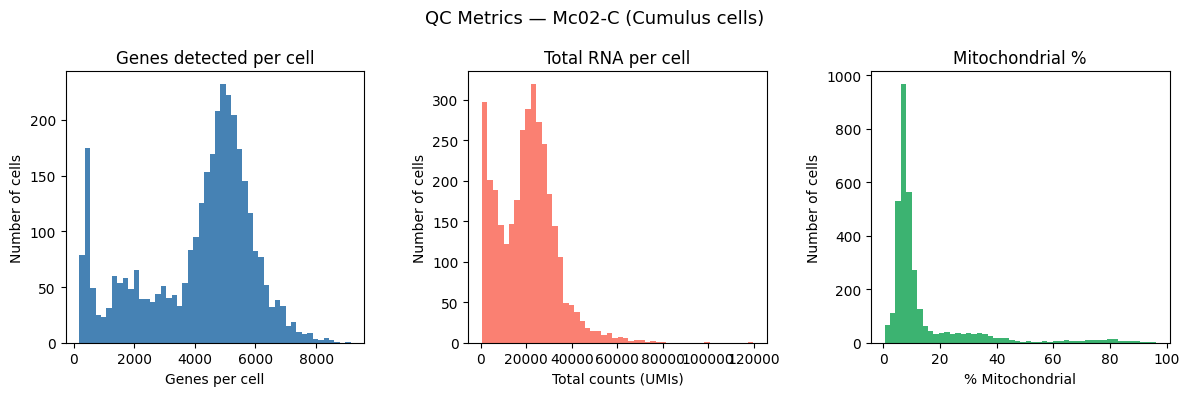

       n_genes_by_counts  total_counts  pct_counts_mt
count            3361.00       3361.00        3361.00
mean             4119.67      20316.36          14.18
std              1841.79      12683.35          16.28
min               181.00        503.00           0.44
25%              2931.00      10156.00           6.48
50%              4672.00      20882.00           8.13
75%              5361.00      27713.00          12.04
max              9142.00     119823.00          96.25


In [9]:
# visualize QC metrics
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(adata.obs['n_genes_by_counts'], bins=50, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Genes per cell')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Genes detected per cell')

axes[1].hist(adata.obs['total_counts'], bins=50, color='salmon', edgecolor='none')
axes[1].set_xlabel('Total counts (UMIs)')
axes[1].set_ylabel('Number of cells')
axes[1].set_title('Total RNA per cell')

axes[2].hist(adata.obs['pct_counts_mt'], bins=50, color='mediumseagreen', edgecolor='none')
axes[2].set_xlabel('% Mitochondrial')
axes[2].set_ylabel('Number of cells')
axes[2].set_title('Mitochondrial %')

plt.suptitle('QC Metrics — Mc02-C (Cumulus cells)', fontsize=13)
plt.tight_layout()
plt.show()

# summary stats
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe().round(2))

In [10]:
# filter low quality cells
print("Before filtering:", adata.shape)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 25].copy()

print("After filtering:", adata.shape)
print(f"Removed {3361 - adata.n_obs} low quality cells")

Before filtering: (3361, 36601)
After filtering: (2873, 21946)
Removed 488 low quality cells


In [11]:
# normalize
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("Normalization done!")
print("Example — AMH expression across first 5 cells:")
amh_idx = adata.var_names.tolist().index('AMH')
print(adata.X[:5, amh_idx].toarray())

Normalization done!
Example — AMH expression across first 5 cells:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


AMH is only expressed in specific cell types (granulosa cells), not every cell. In a tissue sample most cells won't express any given gene.

In [12]:
print("PCOS gene expression summary:")
pcos_genes = ['AMH', 'FSHR', 'LHCGR', 'CYP17A1', 'CYP11A1', 
              'STAR', 'GDF9', 'VEGFA', 'INSR', 'IGF1']

for gene in pcos_genes:
    if gene not in adata.var_names:
        print(f"  {gene}: filtered out (expressed in <3 cells)")
        continue
    idx = adata.var_names.tolist().index(gene)
    expr = adata.X[:, idx].toarray().flatten()
    pct = (expr > 0).mean() * 100
    mean_expr = expr[expr > 0].mean() if (expr > 0).any() else 0
    print(f"  {gene}: {pct:.1f}% cells express it, mean={mean_expr:.2f}")

PCOS gene expression summary:
  AMH: 1.7% cells express it, mean=0.39
  FSHR: 0.1% cells express it, mean=0.39
  LHCGR: 0.8% cells express it, mean=0.31
  CYP17A1: 2.2% cells express it, mean=0.54
  CYP11A1: 37.1% cells express it, mean=0.56
  STAR: 78.0% cells express it, mean=1.30
  GDF9: 0.3% cells express it, mean=0.31
  VEGFA: 84.1% cells express it, mean=1.16
  INSR: 37.9% cells express it, mean=0.48
  IGF1: 12.1% cells express it, mean=0.53


## PCOS Gene Expression — Mc02-C (Cumulus Cells)

### What we measured
Each percentage = proportion of cells in this sample expressing that gene.
Mean = average expression level in cells that DO express it (log-normalized).

### Results & Biological Significance

| Gene | % Cells | Mean Expr | Role in PCOS |
|------|---------|-----------|--------------|
| STAR | 78.0% | 1.30 | Rate-limiting step in steroidogenesis — moves cholesterol into mitochondria to make androgens. High expression = high androgen production capacity |
| VEGFA | 84.1% | 1.16 | Promotes blood vessel growth. Elevated in PCOS ovaries, linked to follicle arrest and ovarian hyperstimulation syndrome |
| INSR | 37.9% | 0.48 | Insulin receptor. PCOS patients are often insulin resistant — dysregulation here drives androgen overproduction |
| CYP11A1 | 37.1% | 0.56 | First enzyme in steroid hormone synthesis. Converts cholesterol to pregnenolone — upstream of androgen production |
| IGF1 | 12.1% | 0.53 | Insulin-like growth factor. Works alongside insulin to stimulate androgen synthesis in granulosa cells |
| CYP17A1 | 2.2% | 0.54 | Key enzyme that converts androgens — directly responsible for androgen excess in PCOS |
| AMH | 1.7% | 0.39 | Anti-Müllerian Hormone — THE clinical biomarker for PCOS. Elevated AMH = follicle arrest. Low % here because only specialized granulosa cells produce it |
| LHCGR | 0.8% | 0.31 | LH receptor. LH excess drives androgen overproduction in PCOS — receptor expression tells us which cells respond to LH |
| GDF9 | 0.3% | 0.31 | Oocyte-secreted growth factor regulating follicle development. Low expression linked to poor oocyte quality in PCOS |
| FSHR | 0.1% | 0.39 | FSH receptor — only on granulosa cells. Very rare here, consistent with cumulus cell identity |

### Key Insight
STAR and VEGFA being expressed in ~80% of cells tells us this cumulus cell 
population has high steroidogenic and vascular activity — hallmarks of the 
PCOS ovarian microenvironment. AMH and FSHR being rare (<2%) confirms these 
are cumulus cells, not granulosa cells (which would show higher AMH/FSHR).

### Why this matters for diagnosis
Current clinical diagnosis only measures AMH in blood serum — a bulk average 
across all cells. scRNA-seq reveals WHICH cells are driving the signal and 
HOW the entire steroidogenic pathway is activated, not just the endpoint hormone.
This is mechanistic evidence that clinical biomarkers cannot provide.

# All samples

In [13]:
# function to load and annotate one sample
def load_sample(sample_path, condition, disease):
    adata = sc.read_10x_mtx(
        sample_path / 'filtered_feature_bc_matrix',
        var_names='gene_symbols',
        cache=True
    )
    adata.obs['condition'] = condition  # C or F
    adata.obs['disease'] = disease      # PCOS or Endo
    adata.obs['sample'] = sample_path.name
    return adata

print("Function defined — ready to load all samples!")

Function defined — ready to load all samples!


In [14]:
import re

pcos_adatas = []

for sample_path in pcos_samples:
    name = sample_path.name  
    
    # extract patient ID and condition from folder name
    # e.g. "01_4796UPenn_Mc02-C_scRNA-seq_hs_SI-GA-E1" → patient=Mc02, condition=C
    match = re.search(r'Mc(\d+)-([CF])', name)
    patient_id = f"Mc{match.group(1)}"
    condition = match.group(2)  # C or F
    
    adata_i = load_sample(sample_path, condition=condition, disease='PCOS')
    adata_i.obs['patient'] = patient_id
    pcos_adatas.append(adata_i)
    print(f"Loaded {patient_id}-{condition}: {adata_i.n_obs} cells")

print(f"\nTotal PCOS samples loaded: {len(pcos_adatas)}")

Loaded Mc02-C: 3361 cells
Loaded Mc02-F: 4051 cells
Loaded Mc06-C: 2600 cells
Loaded Mc06-F: 4126 cells
Loaded Mc31-C: 2045 cells
Loaded Mc31-F: 4268 cells
Loaded Mc40-C: 2050 cells
Loaded Mc40-F: 4177 cells
Loaded Mc50-C: 4274 cells
Loaded Mc50-F: 5285 cells
Loaded Mc03-C: 3689 cells
Loaded Mc03-F: 4663 cells
Loaded Mc10-C: 2212 cells
Loaded Mc10-F: 4054 cells
Loaded Mc16-C: 3035 cells
Loaded Mc16-F: 3147 cells
Loaded Mc26-C: 2695 cells
Loaded Mc26-F: 2373 cells
Loaded Mc27-C: 2845 cells
Loaded Mc27-F: 5273 cells

Total PCOS samples loaded: 20


In [15]:
endo_adatas = []

for sample_path in endo_samples:
    name = sample_path.name
    # e.g. UA_Endo12269811_FX0022 → patient ID is the number
    match = re.search(r'Endo(\d+)', name)
    patient_id = f"Endo{match.group(1)}"
    
    # endo samples don't have C/F — they're endometrium tissue
    adata_i = sc.read_10x_mtx(
        sample_path,
        var_names='gene_symbols',
        cache=True
    )
    adata_i.obs['condition'] = 'Endo'
    adata_i.obs['disease'] = 'Endo'
    adata_i.obs['patient'] = patient_id
    adata_i.obs['sample'] = name
    endo_adatas.append(adata_i)
    print(f"Loaded {patient_id}: {adata_i.n_obs} cells")

print(f"\nTotal Endo samples loaded: {len(endo_adatas)}")

Loaded Endo12269811: 5734 cells
Loaded Endo12604667: 4844 cells

Total Endo samples loaded: 2


In [16]:
# combine all samples
all_adatas = pcos_adatas + endo_adatas

adata_combined = sc.concat(
    all_adatas,
    label='sample_id',
    keys=[f"{a.obs['patient'].iloc[0]}-{a.obs['condition'].iloc[0]}" for a in all_adatas],
    merge='same'
)

print("Combined adata:")
print(adata_combined)
print("\nDisease distribution:")
print(adata_combined.obs['disease'].value_counts())
print("\nCondition distribution:")
print(adata_combined.obs['condition'].value_counts())

Combined adata:
AnnData object with n_obs × n_vars = 80801 × 36601
    obs: 'condition', 'disease', 'sample', 'patient', 'sample_id'
    var: 'gene_ids', 'feature_types'

Disease distribution:
disease
PCOS    70223
Endo    10578
Name: count, dtype: int64

Condition distribution:
condition
F       41417
C       28806
Endo    10578
Name: count, dtype: int64


/Users/maribels/Desktop/sbs biohack/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
# fix duplicate cell names (different samples can have same barcode)
adata_combined.obs_names_make_unique()

print("Cell names now unique!")
print(f"Total cells: {adata_combined.n_obs:,}")
print(f"Total genes: {adata_combined.n_vars:,}")
print(f"\nPCOS cells: {(adata_combined.obs['disease']=='PCOS').sum():,}")
print(f"Endo cells:  {(adata_combined.obs['disease']=='Endo').sum():,}")

Cell names now unique!
Total cells: 80,801
Total genes: 36,601

PCOS cells: 70,223
Endo cells:  10,578


In [ ]:
#FILTER LOW QUALITY CELLS

# QC on combined data
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata_combined,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

# filter
print("Before filtering:", adata_combined.shape)

sc.pp.filter_cells(adata_combined, min_genes=200) #remove <200 detected
sc.pp.filter_genes(adata_combined, min_cells=3) #remove <3 detected
adata_combined = adata_combined[adata_combined.obs['pct_counts_mt'] < 25].copy() #remove cells where more than 25% RNA is mitochondrial (dying cells)

print("After filtering:", adata_combined.shape)
print(f"Cells removed: {80801 - adata_combined.n_obs:,}")

# check disease balance after filtering
print("\nDisease distribution after QC:")
print(adata_combined.obs['disease'].value_counts())

Before filtering: (80801, 36601)
After filtering: (69833, 32259)
Cells removed: 10,968

Disease distribution after QC:
disease
PCOS    59255
Endo    10578
Name: count, dtype: int64


In [19]:
# normalize
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

# find highly variable genes — most informative for clustering
sc.pp.highly_variable_genes(
    adata_combined, 
    min_mean=0.0125, 
    max_mean=3, 
    min_disp=0.5
)

print("Highly variable genes found:")
print(adata_combined.var['highly_variable'].value_counts())
print("\nAre our PCOS genes highly variable?")
pcos_genes = ['AMH', 'FSHR', 'LHCGR', 'CYP17A1', 'CYP11A1', 'STAR', 'GDF9', 'VEGFA', 'INSR', 'IGF1']
for gene in pcos_genes:
    if gene in adata_combined.var_names:
        hv = adata_combined.var.loc[gene, 'highly_variable']
        print(f"  {gene}: {'✓ highly variable' if hv else '✗ not highly variable'}")

Highly variable genes found:
highly_variable
False    28385
True      3874
Name: count, dtype: int64

Are our PCOS genes highly variable?
  AMH: ✗ not highly variable
  FSHR: ✗ not highly variable
  LHCGR: ✓ highly variable
  CYP17A1: ✓ highly variable
  CYP11A1: ✓ highly variable
  STAR: ✓ highly variable
  GDF9: ✗ not highly variable
  VEGFA: ✓ highly variable
  INSR: ✓ highly variable
  IGF1: ✓ highly variable


the genes that will separate PCOS from endo clusters are the steroidogenesis genes (STAR, CYP17A1, CYP11A1) and metabolic genes (INSR, IGF1).

Rotterdam relies on indirect markers — androgen levels, ultrasound morphology, cycle regularity. scRNA-seq shows the upstream drivers at the cellular level are steroidogenesis genes (STAR, CYP17A1) and insulin signaling (INSR), none of which are directly captured by Rotterdam's three criteria.

Teede HJ, et al. Recommendations from the 2023 International Evidence-based Guideline for the Assessment and Management of Polycystic Ovary Syndrome. J Clin Endocrinol Metab. 2023;108(10):2447–2469. doi:10.1210/clinem/dgad463

PCA done!
Working with 3874 highly variable genes


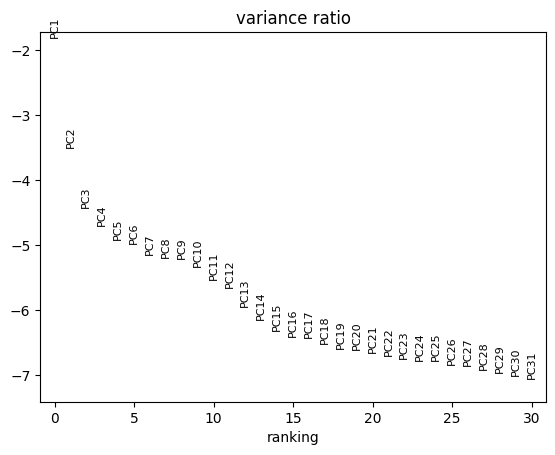

In [21]:
# keep only highly variable genes for downstream analysis
# PC weighted combo of genes, genes w highest weight = PC1
adata_combined.raw = adata_combined  # save full data first
adata_combined = adata_combined[:, adata_combined.var['highly_variable']].copy()

# PCA
sc.pp.scale(adata_combined, max_value=10)
sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)

print("PCA done!")
print(f"Working with {adata_combined.n_vars} highly variable genes")

# variance explained
sc.pl.pca_variance_ratio(adata_combined, n_pcs=30, log=True)

In [22]:
sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=15)
sc.tl.umap(adata_combined)
print("UMAP done! Ready to visualize.")

UMAP done! Ready to visualize.


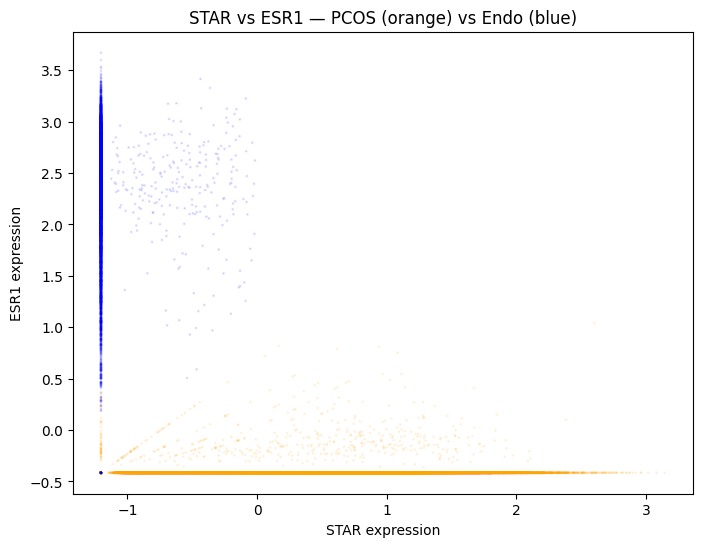

In [34]:
star_idx = adata_combined.var_names.tolist().index('STAR')
esr1_idx = adata_combined.var_names.tolist().index('ESR1')

star_expr = adata_combined.X[:, star_idx].flatten()
esr1_expr = adata_combined.X[:, esr1_idx].flatten()
colors = ['orange' if d == 'PCOS' else 'blue' for d in adata_combined.obs['disease']]

plt.figure(figsize=(8, 6))
plt.scatter(star_expr, esr1_expr, c=colors, alpha=0.1, s=1)
plt.xlabel('STAR expression')
plt.ylabel('ESR1 expression')
plt.title('STAR vs ESR1 — PCOS (orange) vs Endo (blue)')
plt.show()

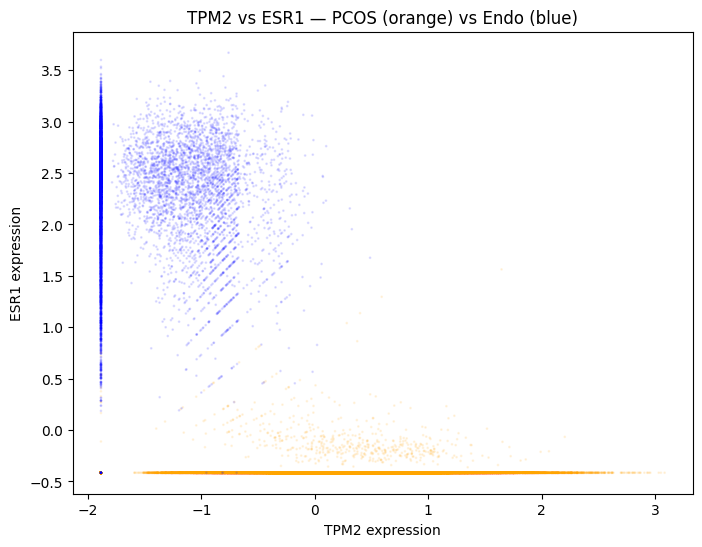

In [35]:
star_idx = adata_combined.var_names.tolist().index('TPM2')
esr1_idx = adata_combined.var_names.tolist().index('ESR1')

star_expr = adata_combined.X[:, star_idx].flatten()
esr1_expr = adata_combined.X[:, esr1_idx].flatten()
colors = ['orange' if d == 'PCOS' else 'blue' for d in adata_combined.obs['disease']]

plt.figure(figsize=(8, 6))
plt.scatter(star_expr, esr1_expr, c=colors, alpha=0.1, s=1)
plt.xlabel('TPM2 expression')
plt.ylabel('ESR1 expression')
plt.title('TPM2 vs ESR1 — PCOS (orange) vs Endo (blue)')
plt.show()

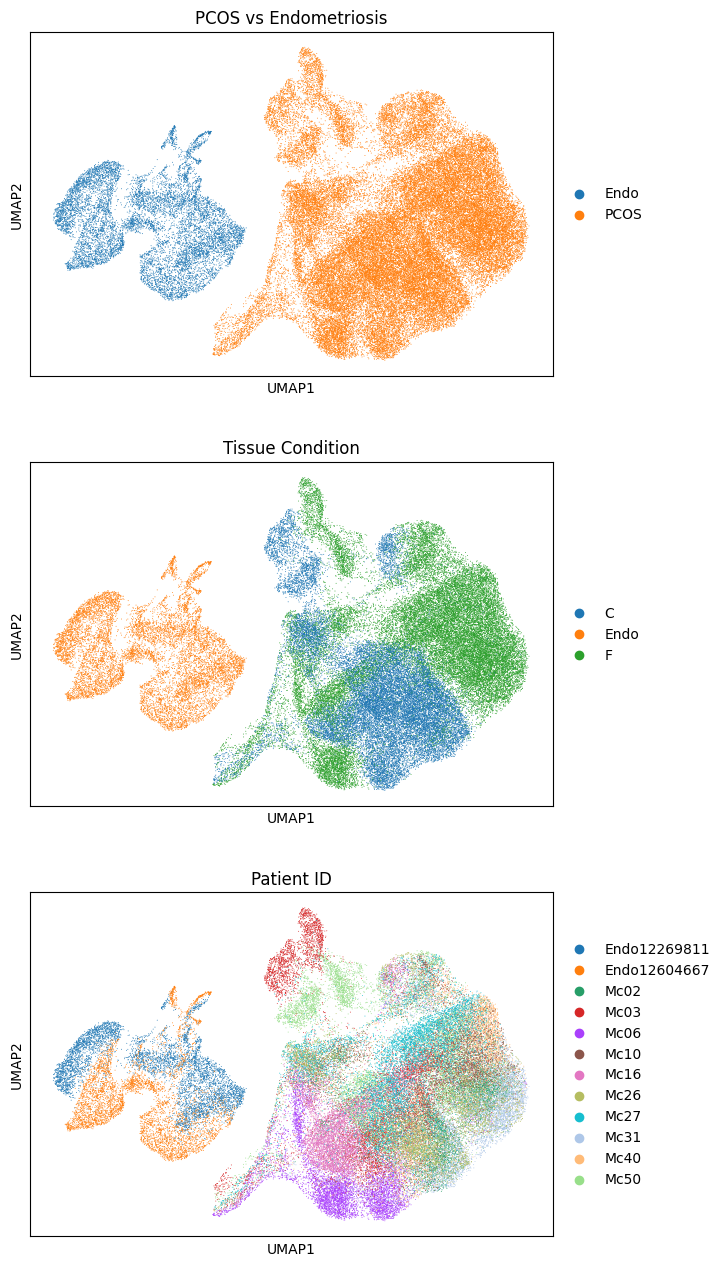

In [23]:
# plot UMAP colored by disease (PCOS vs Endo)
sc.pl.umap(
    adata_combined,
    color=['disease', 'condition', 'patient'],
    ncols=1,
    title=['PCOS vs Endometriosis', 'Tissue Condition', 'Patient ID']
)

to note that within pcos itself individual patients are clustered separately. PCOS and endometriosis have molecularly distinct cellular signatures, separating clearly in unsupervised UMAP space. This molecular distinctiveness, invisible to clinical criteria, provides the biological rationale for why these conditions can and should be differentiable diagnostically.

/Users/maribels/Desktop/sbs biohack/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/maribels/Desktop/sbs biohack/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


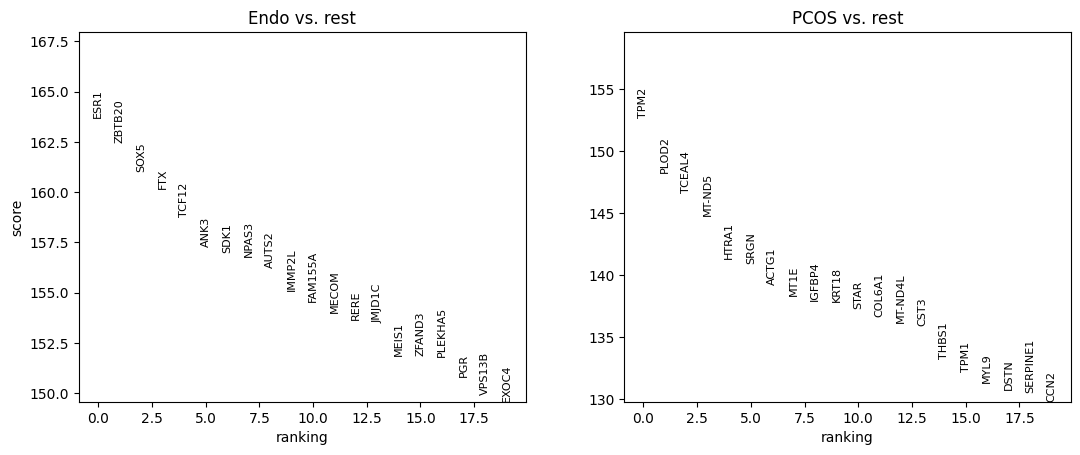

In [24]:
# find marker genes — PCOS vs Endo
sc.tl.rank_genes_groups(
    adata_combined,
    groupby='disease',
    method='wilcoxon',
    key_added='pcos_vs_endo'
)

# show top 20 genes for each group
sc.pl.rank_genes_groups(
    adata_combined,
    n_genes=20,
    key='pcos_vs_endo',
    sharey=False,
    title='Top differentially expressed genes'
)

In [25]:
# get results as a clean dataframe
result = sc.get.rank_genes_groups_df(
    adata_combined,
    group='PCOS',
    key='pcos_vs_endo'
)

print("Top 20 PCOS marker genes:")
print(result.head(20).to_string())

# check where our known PCOS genes rank
print("\nWhere do known PCOS genes rank?")
pcos_genes = ['STAR', 'VEGFA', 'INSR', 'IGF1', 'CYP17A1', 'CYP11A1', 'AMH', 'FSHR']
for gene in pcos_genes:
    if gene in result['names'].values:
        rank = result[result['names']==gene].index[0]
        score = result[result['names']==gene]['scores'].values[0]
        print(f"  {gene}: rank {rank}, score {score:.2f}")
    else:
        print(f"  {gene}: not found")

Top 20 PCOS marker genes:
       names      scores  logfoldchanges  pvals  pvals_adj
0       TPM2  152.711472             NaN    0.0        0.0
1      PLOD2  148.249283             NaN    0.0        0.0
2     TCEAL4  146.663559             NaN    0.0        0.0
3     MT-ND5  144.760803             NaN    0.0        0.0
4      HTRA1  141.345932             NaN    0.0        0.0
5       SRGN  140.901413             NaN    0.0        0.0
6      ACTG1  139.192276             NaN    0.0        0.0
7       MT1E  138.323013             NaN    0.0        0.0
8     IGFBP4  137.933502             NaN    0.0        0.0
9      KRT18  137.836014             NaN    0.0        0.0
10      STAR  137.289963             NaN    0.0        0.0
11    COL6A1  136.659683             NaN    0.0        0.0
12   MT-ND4L  136.167007             NaN    0.0        0.0
13      CST3  135.893982             NaN    0.0        0.0
14     THBS1  133.252380             NaN    0.0        0.0
15      TPM1  132.241699      

In [26]:
# fix logfoldchanges — recalculate properly
result_pcos = sc.get.rank_genes_groups_df(
    adata_combined,
    group='PCOS',
    key='pcos_vs_endo'
).dropna()

result_endo = sc.get.rank_genes_groups_df(
    adata_combined,
    group='Endo',
    key='pcos_vs_endo'
).dropna()

print("Top 15 PCOS markers (with fold change):")
print(result_pcos.head(15)[['names', 'scores', 'logfoldchanges']].to_string())

print("\nTop 15 Endo markers (with fold change):")
print(result_endo.head(15)[['names', 'scores', 'logfoldchanges']].to_string())

Top 15 PCOS markers (with fold change):
          names    scores  logfoldchanges
432     C1orf56  9.539414       -4.450250
449       UBE2T  8.404815       -2.672990
465        DYSF  8.002209        2.931978
468       LIN7B  7.790900        0.957771
503      SLC4A3  6.030049       -2.818721
523       LCMT2  5.541899       -2.831840
524     ALDH4A1  5.533492       -4.248617
533     C4orf46  5.258060       -2.520788
537   ARHGAP11A  5.115603       -3.450652
549  AC093297.2  4.799774       -2.470740
560  AC007563.2  4.599770       -2.587914
582        BEX2  4.215007       -0.136369
584  AC092903.2  4.090662       -4.802430
590    HIST1H1A  3.944179       -8.961122
595       KRT81  3.810670       -6.058464

Top 15 Endo markers (with fold change):
           names    scores  logfoldchanges
3111        CST1  0.039878       -0.041987
3116      DLGAP5 -0.063488        2.562242
3121        HMMR -0.146802        0.358980
3125         LEP -0.241048        0.152867
3139       ADH1B -0.572313      

In [27]:
# correct approach — rerun with logfoldchanges explicitly requested
sc.tl.rank_genes_groups(
    adata_combined,
    groupby='disease',
    method='wilcoxon',
    key_added='pcos_vs_endo',
    rankby_abs=False
)

# extract properly
result_pcos = sc.get.rank_genes_groups_df(
    adata_combined,
    group='PCOS',
    key='pcos_vs_endo'
)

result_endo = sc.get.rank_genes_groups_df(
    adata_combined,
    group='Endo',
    key='pcos_vs_endo'
)

print("Top 15 PCOS markers:")
print(result_pcos.head(15)[['names', 'scores', 'pvals_adj']].to_string())

print("\nTop 15 Endo markers:")
print(result_endo.head(15)[['names', 'scores', 'pvals_adj']].to_string())

Top 15 PCOS markers:
      names      scores  pvals_adj
0      TPM2  152.711472        0.0
1     PLOD2  148.249283        0.0
2    TCEAL4  146.663559        0.0
3    MT-ND5  144.760803        0.0
4     HTRA1  141.345932        0.0
5      SRGN  140.901413        0.0
6     ACTG1  139.192276        0.0
7      MT1E  138.323013        0.0
8    IGFBP4  137.933502        0.0
9     KRT18  137.836014        0.0
10     STAR  137.289963        0.0
11   COL6A1  136.659683        0.0
12  MT-ND4L  136.167007        0.0
13     CST3  135.893982        0.0
14    THBS1  133.252380        0.0

Top 15 Endo markers:
      names      scores  pvals_adj
0      ESR1  163.715607        0.0
1    ZBTB20  162.443771        0.0
2      SOX5  161.022217        0.0
3       FTX  160.186111        0.0
4     TCF12  158.759338        0.0
5      ANK3  157.266174        0.0
6      SDK1  156.990143        0.0
7     NPAS3  156.775742        0.0
8     AUTS2  156.249710        0.0
9    IMMP2L  155.075333        0.0
10  FAM155A 

/Users/maribels/Desktop/sbs biohack/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/maribels/Desktop/sbs biohack/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


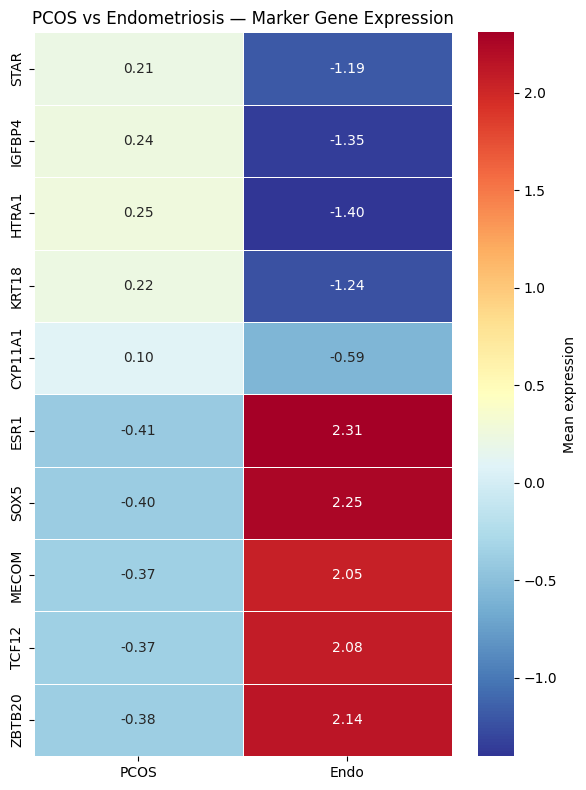

In [30]:
import seaborn as sns

genes_of_interest = ['STAR', 'IGFBP4', 'HTRA1', 'KRT18', 'CYP11A1', 
                     'ESR1', 'SOX5', 'MECOM', 'TCF12', 'ZBTB20']

expr_data = {}
for disease in ['PCOS', 'Endo']:
    mask = adata_combined.obs['disease'] == disease
    subset = adata_combined[mask]
    means = []
    for gene in genes_of_interest:
        if gene in adata_combined.var_names:
            idx = adata_combined.var_names.tolist().index(gene)
            means.append(subset.X[:, idx].toarray().flatten().mean())
        else:
            means.append(0)
    expr_data[disease] = means

df_heat = pd.DataFrame(expr_data, index=genes_of_interest)

plt.figure(figsize=(6, 8))
sns.heatmap(df_heat, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            linewidths=0.5, cbar_kws={'label': 'Mean expression'})
plt.title('PCOS vs Endometriosis — Marker Gene Expression')
plt.tight_layout()
plt.show()

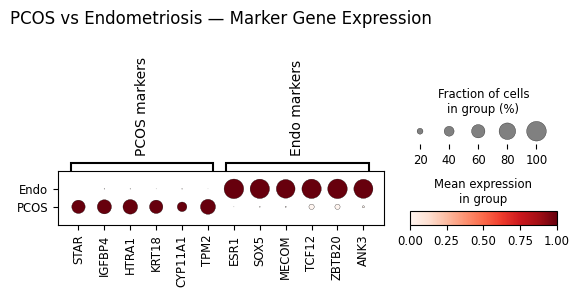

In [28]:
# dotplot of key marker genes
marker_genes = {
    'PCOS markers': ['STAR', 'IGFBP4', 'HTRA1', 'KRT18', 'CYP11A1', 'TPM2'],
    'Endo markers': ['ESR1', 'SOX5', 'MECOM', 'TCF12', 'ZBTB20', 'ANK3']
}

sc.pl.dotplot(
    adata_combined,
    marker_genes,
    groupby='disease',
    title='PCOS vs Endometriosis — Marker Gene Expression',
    standard_scale='var'
)

In [36]:
# verify PCOS gene expression across full combined dataset
genes_to_check = ['STAR', 'VEGFA', 'IGFBP4', 'CYP11A1', 'AMH', 'ESR1']

print("Gene expression across full combined dataset:")
print(f"{'Gene':<12} {'% PCOS cells':<18} {'% Endo cells':<18}")
print("-" * 48)

for gene in genes_to_check:
    if gene not in adata_combined.var_names:
        print(f"{gene:<12} filtered out during QC")
        continue
    
    idx = adata_combined.var_names.tolist().index(gene)
    
    pcos_mask = adata_combined.obs['disease'] == 'PCOS'
    endo_mask = adata_combined.obs['disease'] == 'Endo'
    
    pcos_expr = adata_combined.X[pcos_mask, idx].flatten()
    endo_expr = adata_combined.X[endo_mask, idx].flatten()
    
    pcos_pct = (pcos_expr > 0).mean() * 100
    endo_pct = (endo_expr > 0).mean() * 100
    
    print(f"{gene:<12} {pcos_pct:<18.1f} {endo_pct:<18.1f}")

Gene expression across full combined dataset:
Gene         % PCOS cells       % Endo cells      
------------------------------------------------
STAR         59.7               0.0               
VEGFA        42.1               21.7              
IGFBP4       64.8               0.9               
CYP11A1      38.4               1.0               
AMH          filtered out during QC
ESR1         0.2                99.8              


In [37]:
result_pcos = sc.get.rank_genes_groups_df(
    adata_combined,
    group='PCOS',
    key='pcos_vs_endo'
)

result_endo = sc.get.rank_genes_groups_df(
    adata_combined,
    group='Endo',
    key='pcos_vs_endo'
)

print("Top 15 PCOS markers (full 69,833 cell dataset):")
print(result_pcos[['names', 'scores', 'pvals_adj']].head(15).to_string())

print("\nTop 15 Endo markers (full 69,833 cell dataset):")
print(result_endo[['names', 'scores', 'pvals_adj']].head(15).to_string())

print("\nWhere do our key genes rank?")
for gene in ['STAR', 'IGFBP4', 'CYP11A1', 'VEGFA', 'ESR1']:
    if gene in result_pcos['names'].values:
        rank = result_pcos[result_pcos['names']==gene].index[0]
        score = result_pcos[result_pcos['names']==gene]['scores'].values[0]
        print(f"  {gene}: rank {rank}, score {score:.2f}")
    elif gene in result_endo['names'].values:
        rank = result_endo[result_endo['names']==gene].index[0]
        score = result_endo[result_endo['names']==gene]['scores'].values[0]
        print(f"  {gene}: TOP ENDO marker, rank {rank}, score {score:.2f}")

Top 15 PCOS markers (full 69,833 cell dataset):
      names      scores  pvals_adj
0      TPM2  152.711472        0.0
1     PLOD2  148.249283        0.0
2    TCEAL4  146.663559        0.0
3    MT-ND5  144.760803        0.0
4     HTRA1  141.345932        0.0
5      SRGN  140.901413        0.0
6     ACTG1  139.192276        0.0
7      MT1E  138.323013        0.0
8    IGFBP4  137.933502        0.0
9     KRT18  137.836014        0.0
10     STAR  137.289963        0.0
11   COL6A1  136.659683        0.0
12  MT-ND4L  136.167007        0.0
13     CST3  135.893982        0.0
14    THBS1  133.252380        0.0

Top 15 Endo markers (full 69,833 cell dataset):
      names      scores  pvals_adj
0      ESR1  163.715607        0.0
1    ZBTB20  162.443771        0.0
2      SOX5  161.022217        0.0
3       FTX  160.186111        0.0
4     TCF12  158.759338        0.0
5      ANK3  157.266174        0.0
6      SDK1  156.990143        0.0
7     NPAS3  156.775742        0.0
8     AUTS2  156.249710     